In [1]:
import json
tr_json_path = '/home/work/hocheol_dir/workspace/data/034_cropped_data/origin/train.json'
val_json_path = '/home/work/hocheol_dir/workspace/data/034_cropped_data/origin/val.json'

tr_json = None
val_json = None

with open(tr_json_path, 'r') as f:
    tr_json = json.load(f)
with open(val_json_path, 'r') as f:
    val_json = json.load(f)
len(tr_json), len(val_json)

(4452, 574)

In [2]:
tr_json = [data for data in tr_json if '_46' not in data['id']]
val_json = [data for data in val_json if '_46' not in data['id']]

In [3]:
len(tr_json), len(val_json), len(tr_json)+len(val_json), 2513*2

(2226, 287, 2513, 5026)

In [4]:
# tr_json과 val_json의 각 클래스 비율!

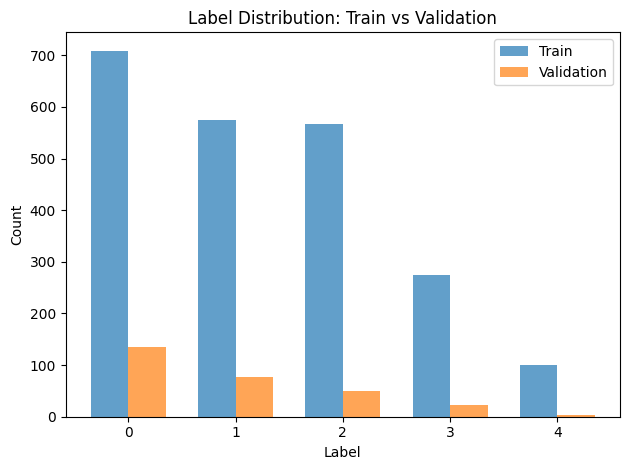

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
# 🔹 라벨 분포 계산
tr_counts = Counter([item["label"] for item in tr_json])
val_counts = Counter([item["label"] for item in val_json])

# 🔹 시각화
labels = sorted(set(tr_counts.keys()) | set(val_counts.keys()))
tr_values = [tr_counts.get(label, 0) for label in labels]
val_values = [val_counts.get(label, 0) for label in labels]

x = range(len(labels))
bar_width = 0.35

plt.bar(x, tr_values, width=bar_width, label="Train", alpha=0.7)
plt.bar([i + bar_width for i in x], val_values, width=bar_width, label="Validation", alpha=0.7)

plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution: Train vs Validation")
plt.xticks([i + bar_width / 2 for i in x], labels)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
df = pd.DataFrame(columns=['tr_num', 'val_num', 'tr_ratio', 'val_ratio', 'total'])

for i in range(5):
    total = tr_counts[i] + val_counts[i]
    row = []
    row.append(tr_counts[i])
    row.append(val_counts[i])
    row.append(tr_counts[i]/total)
    row.append(val_counts[i]/total)
    row.append(total)

    df.loc[len(df)] = row
df

,tr_num,val_num,tr_ratio,val_ratio,total
0,709.0,136.0,0.839053,0.160947,845.0
1,575.0,76.0,0.883257,0.116743,651.0
2,566.0,49.0,0.920325,0.079675,615.0
3,275.0,22.0,0.925926,0.074074,297.0
4,101.0,4.0,0.961905,0.038095,105.0


하나의 id에 19, 46 두개의 라벨 붙는다. id별로 나눠

In [7]:
import json
from collections import defaultdict
from sklearn.model_selection import train_test_split

# 🔹 JSON 파일 불러오기
with open("/home/work/hocheol_dir/workspace/data/034_cropped_data/origin/train.json", "r") as f:
    tr_json = json.load(f)
with open("/home/work/hocheol_dir/workspace/data/034_cropped_data/origin/val.json", "r") as f:
    val_json = json.load(f)

all_data = tr_json + val_json

# 🔹 ID 기준으로 묶기
id_group = defaultdict(list)
id_label = {}  # 대표 label 저장용

for item in all_data:
    id_key = item['id'].split("_")[0]
    id_group[id_key].append(item)
    if id_key not in id_label:
        id_label[id_key] = item['label']  # 대표 라벨 하나 사용

# 🔹 ID 리스트 및 라벨 리스트
id_list = list(id_group.keys())
label_list = [id_label[_id] for _id in id_list]

# 🔹 ID 기준 stratify split (8:1:1)
train_ids, temp_ids, _, temp_labels = train_test_split(
    id_list, label_list, test_size=0.2, stratify=label_list, random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, stratify=temp_labels, random_state=42
)

# 🔹 실제 데이터 분리
train_data = [item for _id in train_ids for item in id_group[_id]]
val_data = [item for _id in val_ids for item in id_group[_id]]
test_data = [item for _id in test_ids for item in id_group[_id]]

# 🔹 확인
print(f"Train: {len(train_data)} samples")
print(f"Val: {len(val_data)} samples")
print(f"Test: {len(test_data)} samples")

# 필요 시 저장
# with open("train.json", "w") as f: json.dump(train_data, f, indent=2)
# with open("val.json", "w") as f: json.dump(val_data, f, indent=2)
# with open("test.json", "w") as f: json.dump(test_data, f, indent=2)


Train: 4020 samples
Val: 502 samples
Test: 504 samples


In [8]:
from collections import Counter
import pandas as pd

df = pd.DataFrame(columns=['tr_num', 'val_num', 'test_num', 'tr_ratio', 'val_ratio', 'test_ratio', 'total'])
# 🔹 라벨 분포 계산
tr_counts = Counter([item["label"] for item in train_data])
val_counts = Counter([item["label"] for item in val_data])
test_counts = Counter([item['label'] for item in test_data])

for i in range(5):
    total = tr_counts[i] + val_counts[i] + test_counts[i]
    row = []
    row.append(tr_counts[i])
    row.append(val_counts[i])
    row.append(test_counts[i])

    row.append(tr_counts[i]/total)
    row.append(val_counts[i]/total)
    row.append(test_counts[i]/total)
    row.append(total)

    df.loc[len(df)] = row
df

,tr_num,val_num,test_num,tr_ratio,val_ratio,test_ratio,total
0,1349.0,170.0,171.0,0.798225,0.100592,0.101183,1690.0
1,1047.0,127.0,130.0,0.802914,0.097393,0.099693,1304.0
2,977.0,122.0,123.0,0.799509,0.099836,0.100655,1222.0
3,473.0,61.0,60.0,0.796296,0.102694,0.101010,594.0
4,174.0,22.0,20.0,0.805556,0.101852,0.092593,216.0


In [9]:
train_data.sort(key=lambda x:x['id'])
val_data.sort(key=lambda x:x['id'])
test_data.sort(key=lambda x:x['id'])

In [10]:
import os
tmp_dir = '/home/work/hocheol_dir/workspace/data/034_cropped_data/tmp'
os.makedirs(tmp_dir, exist_ok=True)

with open(os.path.join(tmp_dir, 'train.json'), 'w') as f:
    json.dump(train_data, f, indent=2, ensure_ascii=False)
with open(os.path.join(tmp_dir, 'val.json'), 'w') as f:
    json.dump(val_data, f, indent=2, ensure_ascii=False)
with open(os.path.join(tmp_dir, 'test.json'), 'w') as f:
    json.dump(test_data, f, indent=2, ensure_ascii=False)

In [11]:
root_dir = '/home/work/hocheol_dir/workspace/data/034_cropped_data'
os.makedirs(os.path.join(root_dir, 'Training'), exist_ok=True)
os.makedirs(os.path.join(root_dir, 'Validation'), exist_ok=True)
os.makedirs(os.path.join(root_dir, 'Test'), exist_ok=True)

In [12]:
import shutil
import copy

new_tr_data = []
new_val_data = []
new_test_data = []

for data in train_data:
    print(root_dir, 'Training')
    origin_left = os.path.join(root_dir, data['left_cheek_path'])
    origin_right = os.path.join(root_dir, data['right_cheek_path'])

    target_dir = os.path.join(root_dir)

    new_left_path = data['left_cheek_path'].replace(data['left_cheek_path'].split('/')[0], 'Training')
    new_right_path = data['right_cheek_path'].replace(data['right_cheek_path'].split('/')[0], 'Training')

    os.makedirs(os.path.join(target_dir, 'Training', data['id'].split('_')[0]), exist_ok=True)
    
    target_left = os.path.join(target_dir, new_left_path)
    target_right = os.path.join(target_dir, new_right_path)
    # shutil.copy(origin_left, target_left)
    # shutil.copy(origin_right, target_right)

    print(data)
    print(origin_left, origin_right)
    print(target_right, target_right)

    new_data = copy.deepcopy(data)
    new_data['left_cheek_path'] = new_left_path
    new_data['right_cheek_path'] = new_right_path

    new_tr_data.append(new_data)

for data in val_data:
    print(root_dir, 'Validation')
    origin_left = os.path.join(root_dir, data['left_cheek_path'])
    origin_right = os.path.join(root_dir, data['right_cheek_path'])

    target_dir = os.path.join(root_dir)

    new_left_path = data['left_cheek_path'].replace(data['left_cheek_path'].split('/')[0], 'Validation')
    new_right_path = data['right_cheek_path'].replace(data['right_cheek_path'].split('/')[0], 'Validation')

    os.makedirs(os.path.join(target_dir, 'Validation', data['id'].split('_')[0]), exist_ok=True)
    
    target_left = os.path.join(target_dir, new_left_path)
    target_right = os.path.join(target_dir, new_right_path)
    # shutil.copy(origin_left, target_left)
    # shutil.copy(origin_right, target_right)

    print(data)
    print(origin_left, origin_right)
    print(target_right, target_right)

    new_data = copy.deepcopy(data)
    new_data['left_cheek_path'] = new_left_path
    new_data['right_cheek_path'] = new_right_path

    new_val_data.append(new_data)

for data in test_data:
    print(root_dir, 'Test')
    origin_left = os.path.join(root_dir, data['left_cheek_path'])
    origin_right = os.path.join(root_dir, data['right_cheek_path'])

    target_dir = os.path.join(root_dir)

    new_left_path = data['left_cheek_path'].replace(data['left_cheek_path'].split('/')[0], 'Test')
    new_right_path = data['right_cheek_path'].replace(data['right_cheek_path'].split('/')[0], 'Test')

    os.makedirs(os.path.join(target_dir, 'Test', data['id'].split('_')[0]), exist_ok=True)
    
    target_left = os.path.join(target_dir, new_left_path)
    target_right = os.path.join(target_dir, new_right_path)
    # shutil.copy(origin_left, target_left)
    # shutil.copy(origin_right, target_right)

    print(data)
    print(origin_left, origin_right)
    print(target_right, target_right)

    new_data = copy.deepcopy(data)
    new_data['left_cheek_path'] = new_left_path
    new_data['right_cheek_path'] = new_right_path

    new_test_data.append(new_data)

# new_tr_data, new_val_data, new_test_data

/home/work/hocheol_dir/workspace/data/034_cropped_data Training
{'id': '0000_19', 'left_cheek_path': '1-2.Training/0000/left_cheek_0000_CRS_19_01.jpg', 'right_cheek_path': '1-2.Training/0000/right_cheek_0000_CRS_19_01.jpg', 'label': 0}
/home/work/hocheol_dir/workspace/data/034_cropped_data/1-2.Training/0000/left_cheek_0000_CRS_19_01.jpg /home/work/hocheol_dir/workspace/data/034_cropped_data/1-2.Training/0000/right_cheek_0000_CRS_19_01.jpg
/home/work/hocheol_dir/workspace/data/034_cropped_data/Training/0000/right_cheek_0000_CRS_19_01.jpg /home/work/hocheol_dir/workspace/data/034_cropped_data/Training/0000/right_cheek_0000_CRS_19_01.jpg
/home/work/hocheol_dir/workspace/data/034_cropped_data Training
{'id': '0000_46', 'left_cheek_path': '1-2.Training/0000/left_cheek_0000_CRS_46_01.jpg', 'right_cheek_path': '1-2.Training/0000/right_cheek_0000_CRS_46_01.jpg', 'label': 0}
/home/work/hocheol_dir/workspace/data/034_cropped_data/1-2.Training/0000/left_cheek_0000_CRS_46_01.jpg /home/work/hocheol

In [13]:
new_tr_data

[{'id': '0000_19',
  'left_cheek_path': 'Training/0000/left_cheek_0000_CRS_19_01.jpg',
  'right_cheek_path': 'Training/0000/right_cheek_0000_CRS_19_01.jpg',
  'label': 0},
 {'id': '0000_46',
  'left_cheek_path': 'Training/0000/left_cheek_0000_CRS_46_01.jpg',
  'right_cheek_path': 'Training/0000/right_cheek_0000_CRS_46_01.jpg',
  'label': 0},
 {'id': '0003_19',
  'left_cheek_path': 'Training/0003/left_cheek_0003_CRS_19_01.jpg',
  'right_cheek_path': 'Training/0003/right_cheek_0003_CRS_19_01.jpg',
  'label': 2},
 {'id': '0003_46',
  'left_cheek_path': 'Training/0003/left_cheek_0003_CRS_46_01.jpg',
  'right_cheek_path': 'Training/0003/right_cheek_0003_CRS_46_01.jpg',
  'label': 2},
 {'id': '0004_19',
  'left_cheek_path': 'Training/0004/left_cheek_0004_CRS_19_01.jpg',
  'right_cheek_path': 'Training/0004/right_cheek_0004_CRS_19_01.jpg',
  'label': 3},
 {'id': '0004_46',
  'left_cheek_path': 'Training/0004/left_cheek_0004_CRS_46_01.jpg',
  'right_cheek_path': 'Training/0004/right_cheek_0004

In [14]:
with open('/home/work/hocheol_dir/workspace/data/merged_data/merged_6ch/train.json', 'w') as f:
    json.dump(new_tr_data, f, indent=2, ensure_ascii=False)
with open('/home/work/hocheol_dir/workspace/data/merged_data/merged_6ch/val.json', 'w') as f:
    json.dump(new_val_data, f, indent=2, ensure_ascii=False)
with open('/home/work/hocheol_dir/workspace/data/merged_data/merged_6ch/test.json', 'w') as f:
    json.dump(new_test_data, f, indent=2, ensure_ascii=False)